In [197]:
!pip install langchain langchain_openai langsmith pandas langchain_experimental matplotlib langgraph langchain_core duckduckgo-search langchain-community chromadb numexpr

In [198]:
import os
from uuid import uuid4

In [199]:
unique_id = uuid4().hex[0:8]
os.environ['LANGCHAIN_TRACING_V2'] = 'true'
os.environ['LANGCHAIN_PROJECT'] = f'LLMCompiler - {unique_id}'
os.environ['LANGCHAIN_ENDPOINT'] = 'https://api.smith.langchain.com'
os.environ['LANGCHAIN_API_KEY'] = ''
os.environ['OPENAI_API_KEY'] = ''
os.environ['TAVILY_API_KEY'] = ''

In [200]:
import math
import re
import numexpr
from typing import List, Optional
from langchain_core.output_parsers import PydanticOutputParser
from langchain_core.messages import SystemMessage
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder
from langchain_core.runnables import RunnableConfig
from langchain_core.tools import StructuredTool
from langchain_openai import ChatOpenAI
from pydantic import BaseModel, Field

In [201]:
_MATH_DESCRIPTION = (
    "math(problem: str, context: Optional[list[str]]) -> float:\n"
    " - Solves the provided math problem.\n"
    ' - `problem` can be either a simple math problem (e.g. "1 + 3") or a word problem (e.g. "how many apples are there if there are 3 apples and 2 apples").\n'
    " - You cannot calculate multiple expressions in one call. For instance, `math('1 + 3, 2 + 4')` does not work. "
    "If you need to calculate multiple expressions, you need to call them separately like `math('1 + 3')` and then `math('2 + 4')`\n"
    " - Minimize the number of `math` actions as much as possible. For instance, instead of calling "
    '2. math("what is the 10% of $1") and then call 3. math("$1 + $2"), '
    'you MUST call 2. math("what is the 110% of $1") instead, which will reduce the number of math actions.\n'
    # Context specific rules below
    " - You can optionally provide a list of strings as `context` to help the agent solve the problem. "
    "If there are multiple contexts you need to answer the question, you can provide them as a list of strings.\n"
    " - `math` action will not see the output of the previous actions unless you provide it as `context`. "
    "You MUST provide the output of the previous actions as `context` if you need to do math on it.\n"
    " - You MUST NEVER provide `search` type action's outputs as a variable in the `problem` argument. "
    "This is because `search` returns a text blob that contains the information about the entity, not a number or value. "
    "Therefore, when you need to provide an output of `search` action, you MUST provide it as a `context` argument to `math` action. "
    'For example, 1. search("Barack Obama") and then 2. math("age of $1") is NEVER allowed. '
    'Use 2. math("age of Barack Obama", context=["$1"]) instead.\n'
    " - When you ask a question about `context`, specify the units. "
    'For instance, "what is xx in height?" or "what is xx in millions?" instead of "what is xx?"\n'
)


_SYSTEM_PROMPT = """Translate a math problem into a expression that can be executed using Python's numexpr library. Use the output of running this code to answer the question.

Question: ${{Question with math problem.}}


${{single line mathematical expression that solves the problem}}

...numexpr.evaluate(text)...


${{Output of running the code}}

Answer: ${{Answer}}

Begin.

Question: What is 37593 * 67?
ExecuteCode({{code: "37593 * 67"}})
...numexpr.evaluate("37593 * 67")...


2518731

Answer: 2518731

Question: 37593^(1/5)
ExecuteCode({{code: "37593**(1/5)"}})
...numexpr.evaluate("37593**(1/5)")...


8.222831614237718

Answer: 8.222831614237718
"""

_ADDITIONAL_CONTEXT_PROMPT = """The following additional context is provided from other functions.\
    Use it to substitute into any ${{#}} variables or other words in the problem.\
    \n\n${context}\n\nNote that context variables are not defined in code yet.\
You must extract the relevant numbers and directly put them in code."""

class ExecuteCode(BaseModel):
    """The input to the numexpr.evaluate() function."""

    reasoning: str = Field(
        ...,
        description="The reasoning behind the code expression, including how context is included, if applicable.",
    )

    code: str = Field(
        ...,
        description='The simple code expression to execute by numexpr.evaluate().',
    )

def _evaluate_expression(expression: str) -> str:
    try:
        local_dict = {'pi': math.pi, 'e': math.e}
        output = str(
            numexpr.evaluate(
                expression.strip(),
                global_dict={},
                local_dict=local_dict,
            )
        )
    except Exception as e:
        raise ValueError(
            f'Failed to evaluate "{expression}". Raised error: {repr(e)}.'
            " Please try agrin with a vailed numerical expression"
        )
    return re.sub(r"^\[|\]$", "", output)

def get_math_tool(llm:ChatOpenAI):
    prompt = ChatPromptTemplate.from_messages(
        [
            ('system', _SYSTEM_PROMPT),
            ('user', '{problem}'),
            MessagesPlaceholder(variable_name='context', optional=True),
        ]
    )
    extractor = prompt | llm.with_structured_output(ExecuteCode)

    def calculate_expression(
            problem: str,
            context: Optional[List[str]] = None,
            config: Optional[RunnableConfig] = None,
    ):
        chain_input = {'problem':problem}
        if context:
            context_str = '\n'.join(context)
            if context_str.strip():
                context_str = _ADDITIONAL_CONTEXT_PROMPT.format(
                    context = context_str.strip()
                )
                chain_input['context'] = [SystemMessage(content=context_str)]
        code_model = extractor.invoke(chain_input, config)
        try:
            return _evaluate_expression(code_model.code)
        except Exception as e:
            return repr(e)
        
    return StructuredTool.from_function(
        name='math',
        func=calculate_expression,
        description=_MATH_DESCRIPTION,
    )

Output Parser

In [202]:
import ast
import re
from typing import (
    Any,
    Dict,
    Iterator,
    List,
    Optional,
    Sequence,
    Tuple,
    Union
)
from langchain_core.exceptions import OutputParserException
from langchain_core.messages import BaseMessage
from langchain_core.output_parsers.transform import BaseTransformOutputParser
from langchain_core.runnables import RunnableConfig
from langchain_core.tools import BaseTool
from typing_extensions import TypedDict

In [203]:
THOUGHT_PATTERN = r'Thought: ([^\n]*)'
ACTION_PATTERN = r'\n*(\d+)\. (\w+)\((.*)\)(\s*#\w+\n)?'
ID_PATTERN = r'\$\{?(\d+)\}?'
END_OF_PLAN = ''

def _ast_parse(arg: str) -> Any:
    try:
        return ast.literal_eval(arg)
    except:
        return arg
    
def _parse_llm_compiler_action_args(args: str, tool: Union[str, BaseTool]) -> list[Any]:
    """Parse arguments from a string."""
    if args =='':
        return ()
    if isinstance(tool,str):
        return ()
    extracted_args = {}
    tool_key = None
    prev_idx = None
    for key in tool.args.keys():
        if f'{key}=' in args:
            idx = args.index(f'{key}=')
            if prev_idx is not None:
                extracted_args[tool_key] = _ast_parse(
                    args[prev_idx:idx].strip().rstrip(',')
                )
            args = args.split(f'{key}=', 1)[1]
            tool_key = key
            prev_idx = 0
    if prev_idx is not None:
        extracted_args[tool_key] = _ast_parse(
            args[prev_idx:].strip().rstrip(',').rstrip(')')
        )
    return extracted_args

def default_dependency_rule(idx,args: str):
    matches = re.findall(ID_PATTERN, args)
    numbers = [int(match) for match in matches]
    return idx in numbers

def _get_dependencies_from_graph(
        idx: int, tool_name: str, args: Dict[str, Any]
) -> dict[str, list[str]]:
    """Get dependencies from a graph."""
    if tool_name =='join':
        return list(range(1, idx))
    return [i for i in range(1, idx) if default_dependency_rule(i, str(args))]

class Task(TypedDict):
    idx: int
    tool: BaseTool
    args: list
    dependencies: Dict[str, list]
    thought: Optional[str]

def instantiate_task(
        tools: Sequence[BaseTool],
        idx: int,
        tool_name: str,
        args: Union[str, Any],
        thought: Optional[str] = None,
)-> Task:
    if tool_name =='join':
        tool = 'join'
    else:
        try:
            tool = tools[[tool.name for tool in tools].index(tool_name)]
        except ValueError as e:
            raise OutputParserException(f'Tool {tool_name} not found.')
    tool_args = _parse_llm_compiler_action_args(args, tool)
    dependencies = _get_dependencies_from_graph(idx, tool_name, tool_args)

    return Task(
        idx = idx,
        tool = tool,
        args = tool_args,
        dependencies=dependencies,
        thought=thought,
    )

class LLMCompilerPlanParser(BaseTransformOutputParser[dict], extra='allow'):
    """Planning output parser."""

    tools: List[BaseTool]

    def _transform(self, input: Iterator[Union[str, BaseMessage]]) -> Iterator[Task]:
        texts = []
        thought = None
        for chunk in input:
            text = chunk if isinstance(chunk, str) else str(chunk.content) 
            for task, thought in self.ingest_token(text, texts ,thought):
                yield task
        if texts:
            task, _ = self._parse_task(''.join(texts), thought)
            if task:
                yield task

    def parse(self, text: str) -> List[Task]:
        return list(self._transform([text]))
    
    def stream(
            self,
            input: str | BaseMessage,
            config: RunnableConfig | None = None,
            **kwargs: Any | None,
    ) -> Iterator[Task]:
        yield from self.transform([input], config, **kwargs)

    def ingest_token(
            self, token: str, buffer: List[str], thought: Optional[str]
    ) -> Iterator[Tuple[Optional[Task], str]]:
        buffer.append(token)
        if '\n' in token:
            buffer_ = ''.join(buffer).split('\n')
            suffix = buffer_[-1]
            for line in buffer_[:-1]:
                task, thought = self._parse_task(line, thought)
                if task:
                    yield task, thought
            buffer.clear()
            buffer.append(suffix)
    
    def _parse_task(self, line: str, thought: Optional[str] = None):
        task = None
        if match := re.match(THOUGHT_PATTERN, line):
            thought = match.group(1)
        elif match := re.match(ACTION_PATTERN, line):
            idx, tool_name, args, _ = match.groups()
            idx = int(idx)
            task = instantiate_task(
                tools=self.tools,
                idx = idx,
                tool_name = tool_name,
                args = args,
                thought= thought,
            )
            thought = None
        return task, thought

Define Tools

In [204]:
from langchain_community.tools.tavily_search import TavilySearchResults
from langchain_openai import ChatOpenAI

In [205]:
calculate = get_math_tool(ChatOpenAI(model='gpt-4o-mini'))
search = TavilySearchResults(
    max_results = 1,
    description= 'tavily_search_results_json(query="the search query) - a search engine.',
)
tools = [search, calculate]

In [206]:
calculate.invoke(
    {
        'problem': '샌프란시스코의 온도에 5를 더하면 얼마인가요?',
        'context': ['샌프란시스코의 온도는 32도 입니다.'],
    }
)

'37'

Planner

In [207]:
from typing import Sequence
from langchain_core.language_models import BaseChatModel
from langchain_core.messages import (
    BaseMessage,
    FunctionMessage,
    HumanMessage,
    SystemMessage,
)
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.runnables import RunnableBranch
from langchain_core.tools import BaseTool
from langchain_openai import ChatOpenAI
from langchainhub import Client
from langchain_core.load import loads

In [208]:
client = Client()

raw_prompt = client.pull("wfh/llm-compiler")
prompt = loads(raw_prompt)

C:\Users\compro\AppData\Local\Temp\ipykernel_16972\3078992126.py:3: DeprecationWarning: The `langchainhub sdk` is deprecated.
Please use the `langsmith sdk` instead:
  pip install langsmith
Use the `pull_prompt` method.
  raw_prompt = client.pull("wfh/llm-compiler")
c:\Users\compro\anaconda3\Lib\site-packages\langchainhub\client.py:326: DeprecationWarning: The `langchainhub sdk` is deprecated.
Please use the `langsmith sdk` instead:
  pip install langsmith
Use the `pull_prompt` method.
  res_dict = self.pull_repo(owner_repo_commit)
C:\Users\compro\AppData\Local\Temp\ipykernel_16972\3078992126.py:4: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit list of allowed classes (or 'messages' for untrusted input that contains only chat messages) to suppress this warning.
  prompt = loads(raw_prompt)


In [209]:
def create_planner(
        llm: BaseChatModel, tools: Sequence[BaseTool], base_prompt: ChatPromptTemplate
):
    tool_descriptions = '\n'.join(
        f'{i+1}. {tool.description}\n'
        for i, tool in enumerate(tools)
    )
    planner_prompt = base_prompt.partial(
        replan='',
        num_tools=len(tools)
        + 1,
        tool_descriptions = tool_descriptions,
    )
    replanner_prompt = base_prompt.partial(
        replan =' -You are given "Previous Plan" which is the plan that the previous agent create along with the excution results'
        "(given as Observation) of each plan and a general thought (given as Thought) about the executed results."
        'You MUST use these information to create the next plan under "Current Plan".\n'
        ' - When sstarting the Current Plan, you should start with "Thought" that outlines the strategy for the next plan.\n'
        " - In the Current Plan, you chould Never repeat the actions that are already executed in the Previous Plan.\n"
        " - You must continue the task index from the end of the previous one. Do not repeat the indices.",
        num_tools = len(tools) + 1,
        tool_descriptions = tool_descriptions,
    )

    def should_replan(state: list):
        return isinstance(state[-1], SystemMessage)
    
    def wrap_messages(state: list):
        return {'messages': state}
    
    def wrap_and_get_last_index(state: list):
        next_task = 0
        for message in state[::-1]:
            if isinstance(message, FunctionMessage):
                next_task = message.additional_kwargs['idx'] + 1
                break
        state[-1].content = state[-1].content + f' - Begin counting at : {next_task}'
        return {'messages': state}
    
    return (
        RunnableBranch(
            (should_replan, wrap_and_get_last_index | replanner_prompt),
            wrap_messages | planner_prompt,
        )
        | llm
        | LLMCompilerPlanParser(tools=tools)
    )

In [210]:
llm = ChatOpenAI(model='gpt-4o-mini')
planner = create_planner(llm, tools, prompt)

In [211]:
example_question = '샌프란시스코의 온도를 세제곱하면 얼마인가요?'

for task in planner.stream([HumanMessage(content=example_question)]):
    print(task['tool'], task['args'])
    print('---')

description='tavily_search_results_json(query="the search query) - a search engine.' max_results=1 api_wrapper=TavilySearchAPIWrapper(tavily_api_key=SecretStr('**********')) {'query': 'temperature in San Francisco'}
---
name='math' description='math(problem: str, context: Optional[list[str]]) -> float:\n - Solves the provided math problem.\n - `problem` can be either a simple math problem (e.g. "1 + 3") or a word problem (e.g. "how many apples are there if there are 3 apples and 2 apples").\n - You cannot calculate multiple expressions in one call. For instance, `math(\'1 + 3, 2 + 4\')` does not work. If you need to calculate multiple expressions, you need to call them separately like `math(\'1 + 3\')` and then `math(\'2 + 4\')`\n - Minimize the number of `math` actions as much as possible. For instance, instead of calling 2. math("what is the 10% of $1") and then call 3. math("$1 + $2"), you MUST call 2. math("what is the 110% of $1") instead, which will reduce the number of math acti

Task Fetching Unit

In [212]:
import re
import time
from concurrent.futures import ThreadPoolExecutor, wait
from typing import Any, Dict, Iterable, List, Union
from langchain_core.runnables import (
    chain as as_runable,
)
from typing_extensions import TypedDict

In [213]:
def _get_observations(messages: List[BaseMessage]) -> Dict[int, Any]:
    results = {}
    for message in messages[::-1]:
        if isinstance(message, FunctionMessage):
            results[int(message.additional_kwargs['idx'])] = message.content
    return results

class SchedulerInput(TypedDict):
    messages: List[BaseMessage]
    tasks: Iterable[Task]

def _execute_task(task, observations, config):
    tool_to_use = task['tool']
    if isinstance(tool_to_use, str):
        return tool_to_use
    args = task['args']
    try:
        if isinstance(args, str):
            resolved_args = _resolve_arg(args, observations)
        elif isinstance(args, dict):
            resolved_args = {
                key: _resolve_arg(val, observations) for key, val in args.items()
            }
        else:
            resolved_args = args
    except Exception as e:
        return (
            f'ERROR(Failed to call {tool_to_use} with args {args}.)'
            f' Args could not be resolved. Error: {repr(e)}'
        )
    try:
        return tool_to_use.invoke(resolved_args, config)
    except Exception as e:
        return (
            f'ERROR(Failed to call {tool_to_use} with args {args}.)'
            + f' Args resolved to {resolved_args}. Error: {repr(e)}'
        )
    
def _resolve_arg(arg: Union[str, Any], observations: Dict[int, Any]):
    ID_PATTERN = r'\$\{?(\d+)\}?'
    
    def replace_match(match):
        idx = int(match.group(1))
        return str(observations.get(idx, match.group(0)))
    
    if isinstance(arg, str):
        return re.sub(ID_PATTERN, replace_match, arg)
    elif isinstance(arg, list):
        return [_resolve_arg(a, observations) for a in arg]
    else:
        return arg
    
@as_runable
def schedule_task(task_inputs, config):
    task: Task = task_inputs['task']
    observations: Dict[int, Any] = task_inputs['observations']
    try:
        observation = _execute_task(task, observations, config)
    except Exception:
        import traceback

        observation = traceback.format_exception()
    observations[task['idx']] = observation

def schedule_pending_task(
        task: Task, observations: Dict[int, Any], retry_after: float=0.2
):
    while True:
        deps = task['dependencies']
        if deps and (any([dep not in observations for dep in deps])):
            time.sleep(retry_after)
            continue
        schedule_task.invoke({'task': task, 'observations': observations})
        break

@as_runable
def schedule_tasks(scheduler_input: SchedulerInput) -> List[FunctionMessage]:
    """Group the tasks into a DAG schedule."""
    tasks = scheduler_input['tasks']
    args_for_tasks = {}
    messages = scheduler_input['messages']
    observations = _get_observations(messages)
    task_names = {}
    originals = set(observations)
    futures = []
    retry_after = 0.25
    with ThreadPoolExecutor() as executor:
        for task in tasks:
            deps= task['dependencies']
            task_names[task['idx']] = (
                task['tool'] if isinstance(task['tool'], str) else task['tool'].name
            )
            args_for_tasks[task['idx']] = task['args']
            if (deps and (any([dep not in observations for dep in deps]))):
                futures.append(
                    executor.submit(
                        schedule_pending_task, task, observations, retry_after
                    )
                )
            else:
                schedule_task.invoke(dict(task = task, observations = observations))

        wait(futures)
    new_observations = {
        k: (task_names[k], args_for_tasks[k], observations[k])
        for k in sorted(observations.keys() - originals)
    }
    tool_messages = [
        FunctionMessage(
            name = name,
            content = str(obs),
            additional_kwargs={'idx': k, 'args': task_args},
            tool_call_id = k,
        )
        for k, (name, task_args, obs) in new_observations.items()
    ]
    return tool_messages

In [214]:
import itertools

In [215]:
@as_runable
def plan_and_schedule(state):
    messages = state['messages']
    tasks = planner.stream(messages)
    try:
        tasks = itertools.chain([next(tasks)], tasks)
    except StopIteration:
        tasks = iter([])
    scheduled_tasks = schedule_tasks.invoke(
        {
            'messages': messages,
            'tasks': tasks,
        }
    )
    return {'messages': scheduled_tasks}

example plan

In [216]:
example_question

'샌프란시스코의 온도를 세제곱하면 얼마인가요?'

In [217]:
tool_messages = plan_and_schedule.invoke(
    {'messages': [HumanMessage(content=example_question)]}
)['messages']

In [218]:
tool_messages

[FunctionMessage(content='[{\'title\': \'San Francisco, CA Weather Forecast | AccuWeather\', \'url\': \'https://www.accuweather.com/en/us/san-francisco/94103/weather-forecast/347629\', \'content\': "# San Francisco, CA\\n\\nSan Francisco\\n\\nCalifornia\\n\\n## Around the Globe\\n\\nAround the Globe\\n\\n### Hurricane Tracker\\n\\n### Severe Weather\\n\\n### Radar & Maps\\n\\n### News & Features\\n\\n### Astronomy\\n\\n### Business\\n\\n### Climate\\n\\n### Health\\n\\n### Recreation\\n\\n### Sports\\n\\n### Travel\\n\\n### Warnings\\n\\n### Data Suite\\n\\n### Forensics\\n\\n### Advertising\\n\\n### Superior Accuracy™\\n\\n### Video\\n\\n### Winter Center\\n\\n## Today\\n\\n## Today\'s Weather\\n\\nSat, May 23\\n\\nClouds giving way to sun\\nHi: 63°\\n\\nTonight: Mainly clear this evening followed by late-night low clouds\\nLo: 55°\\n\\n## Current Weather\\n\\n2:35 AM\\n\\n## San Francisco Weather Radar\\n\\nSan Francisco Weather Radar\\n\\n## Hourly Weather\\n\\nrain drop\\n\\nrain d

Joiner

In [219]:
from langchain_core.messages import AIMessage
from pydantic import BaseModel, Field

In [220]:
class FinalResponse(BaseModel):
    """The final response/answer."""
    response: str

class Replan(BaseModel):
    feedback : str = Field(
        description='Analysis of the previous attempts and recommendations on what needs to be fixed.'
    )

class JoinOutputs(BaseModel):
    """Decide whether to replan or whether tou cna return the final response."""

    thought: str = Field(
        description='The chain of thought reasoning for the selected action'
    )
    action: Union[FinalResponse, Replan]

joiner_prompt = ChatPromptTemplate.from_messages([
    (
        "system",
        """
You are a task joiner for an LLM compiler agent system.

Your job:
1. Review the completed tool outputs.
2. Determine whether the final answer can be produced.
3. If more tasks are needed, return a replan action.
4. Otherwise return the final response.

You must respond in the required structured format.
Examples:
{examples}
"""
    ),
    (
        "human",
        """
Here are the previous messages:

{messages}
"""
    ),
])

joiner_prompt = joiner_prompt.partial(examples="")

llm = ChatOpenAI(model="gpt-4o-mini")

runnable = joiner_prompt | llm.with_structured_output(JoinOutputs)

In [221]:
joiner_prompt.pretty_print()

================================ System Message ================================


You are a task joiner for an LLM compiler agent system.

Your job:
1. Review the completed tool outputs.
2. Determine whether the final answer can be produced.
3. If more tasks are needed, return a replan action.
4. Otherwise return the final response.

You must respond in the required structured format.
Examples:
{examples}


================================ Human Message =================================


Here are the previous messages:

{messages}



In [222]:
def _parse_joiner_output(decision: JoinOutputs) -> List[BaseMessage]:
    response = [AIMessage(content=f'Thought: {decision.thought}')]
    if isinstance(decision.action, Replan):
        return {
            'messages' : response
            + [
                SystemMessage(
                    content = f'Context from last attemp: {decision.action.feedback}'
                )
            ]
        }
    else:
        return {'messages' : response + [AIMessage(content=decision.action.response)]}
    
def select_recent_messages(state) -> dict:
    messages = state['messages']
    selected = []
    for msg in messages[::-1]:
        selected.append(msg)
        if isinstance(msg, HumanMessage):
            break
        return {'messages': selected[::-1]}
    
joiner = select_recent_messages | runnable | _parse_joiner_output

In [223]:
input_messages = [HumanMessage(content=example_question)] + tool_messages

In [224]:
input_messages

[HumanMessage(content='샌프란시스코의 온도를 세제곱하면 얼마인가요?', additional_kwargs={}, response_metadata={}),
 FunctionMessage(content='[{\'title\': \'San Francisco, CA Weather Forecast | AccuWeather\', \'url\': \'https://www.accuweather.com/en/us/san-francisco/94103/weather-forecast/347629\', \'content\': "# San Francisco, CA\\n\\nSan Francisco\\n\\nCalifornia\\n\\n## Around the Globe\\n\\nAround the Globe\\n\\n### Hurricane Tracker\\n\\n### Severe Weather\\n\\n### Radar & Maps\\n\\n### News & Features\\n\\n### Astronomy\\n\\n### Business\\n\\n### Climate\\n\\n### Health\\n\\n### Recreation\\n\\n### Sports\\n\\n### Travel\\n\\n### Warnings\\n\\n### Data Suite\\n\\n### Forensics\\n\\n### Advertising\\n\\n### Superior Accuracy™\\n\\n### Video\\n\\n### Winter Center\\n\\n## Today\\n\\n## Today\'s Weather\\n\\nSat, May 23\\n\\nClouds giving way to sun\\nHi: 63°\\n\\nTonight: Mainly clear this evening followed by late-night low clouds\\nLo: 55°\\n\\n## Current Weather\\n\\n2:35 AM\\n\\n## San Francisco W

In [225]:
joiner.invoke({'messages': input_messages})

{'messages': [AIMessage(content="Thought: There's not enough information provided in the previous messages to determine if the final answer can be produced or if more tasks are needed. The function message indicates a 'join' operation, but does not specify the outputs to be joined or the desired final outcome. More context is required to proceed effectively.", additional_kwargs={}, response_metadata={}, tool_calls=[], invalid_tool_calls=[]),
  SystemMessage(content='Context from last attemp: The task requires further clarification or additional outputs to be provided before a final response can be constructed. Please provide the specific outputs or responses that need to be joined together or detail what final answer is expected from this joining process.', additional_kwargs={}, response_metadata={})]}

In [226]:
from langgraph.graph import END, StateGraph, START
from langgraph.graph.message import add_messages
from typing import Annotated

In [229]:
class State(TypedDict):
    messages: Annotated[list, add_messages]

graph_builder = StateGraph(State)

graph_builder.add_node('plan_and_schedule', plan_and_schedule)
graph_builder.add_node('join', joiner)

graph_builder.add_edge('plan_and_schedule', 'join')

def should_continue(state):
    messages = state['messages']
    if isinstance(messages[-1], AIMessage):
        return END
    return 'plan_and_schedule'

graph_builder.add_conditional_edges(
    'join',
    should_continue,
)
graph_builder.add_edge(START, 'plan_and_schedule')
chain = graph_builder.compile()

In [230]:
from IPython.display import Image, display

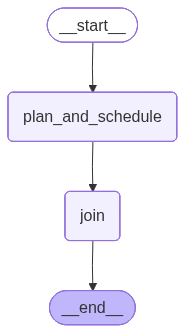

In [232]:
display(Image(chain.get_graph(xray=True).draw_mermaid_png()))

In [233]:
for step in chain.stream(
    {"messages": [HumanMessage(content="대한민국의 2023년 GDP는 얼마인가요?")]}
):
    print(step)
    print("---")

{'plan_and_schedule': {'messages': [FunctionMessage(content="[{'title': '대한민국/GDP - 나무위키', 'url': 'https://namu.wiki/w/%EB%8C%80%ED%95%9C%EB%AF%BC%EA%B5%AD/GDP', 'content': '### 2.3. 2018년(/edit/%EB%8C%80%ED%95%9C%EB%AF%BC%EA%B5%AD/GDP?section=9)\\n\\n#### 2.3.1. 총액 GDP(/edit/%EB%8C%80%ED%95%9C%EB%AF%BC%EA%B5%AD/GDP?section=10)\\n\\n|  |  |  |  |  |  |  |  |  |\\n ---  ---  ---  --- \\n| 국가 | 2016년 | 2017년 | 2018년 추정 | 2019년 추정 | 2020년 추정 | 2021년 추정 | 2022년 추정 | 2023년 추정 |\\n| 대한민국 | 1,414.80 | 1,540.46 | 1,655.61 | 1,699.68 | 1,781.77 | 1,864.79 | 1,959.37 | 2,054.56 |\\n| 3.0 | 3.1 | 2.8 | 2.6 | 2.8 | 2.8 | 2.7 | 2.6 | [...] #### 2.3.2. 1인당 GDP(/edit/%EB%8C%80%ED%95%9C%EB%AF%BC%EA%B5%AD/GDP?section=11)\\n\\n|  |  |  |  |  |  |  |  |  |\\n ---  ---  ---  --- \\n| 국가 | 2016년 | 2017년 | 2018년 추정 | 2019년 추정 | 2020년 추정 | 2021년 추정 | 2022년 추정 | 2023년 추정 |\\n| 대한민국 | 27,608 | 29,938 | 32,046 | 32,766 | 34,209 | 35,658 | 37,315 | 38,969 | [...] #### 2.2.1. 총액 GDP(/edit/%EB%8C%80%ED%95%9C%EB%AF

KeyboardInterrupt: 